# **Visualization**

Shape of dataset: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


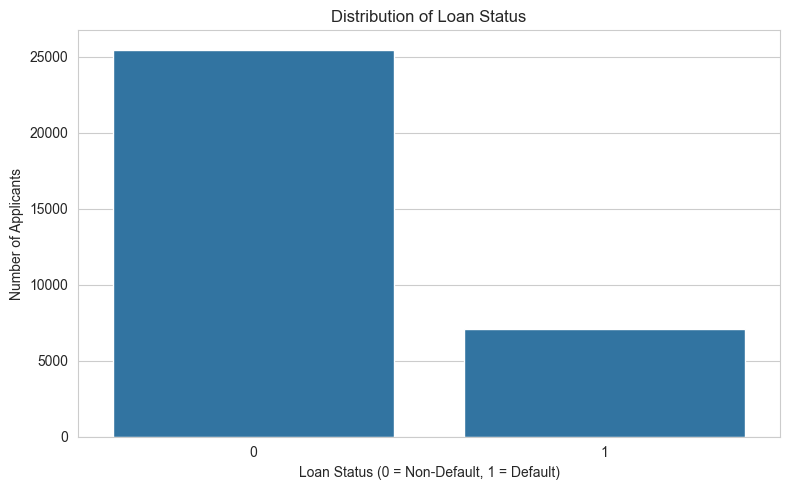

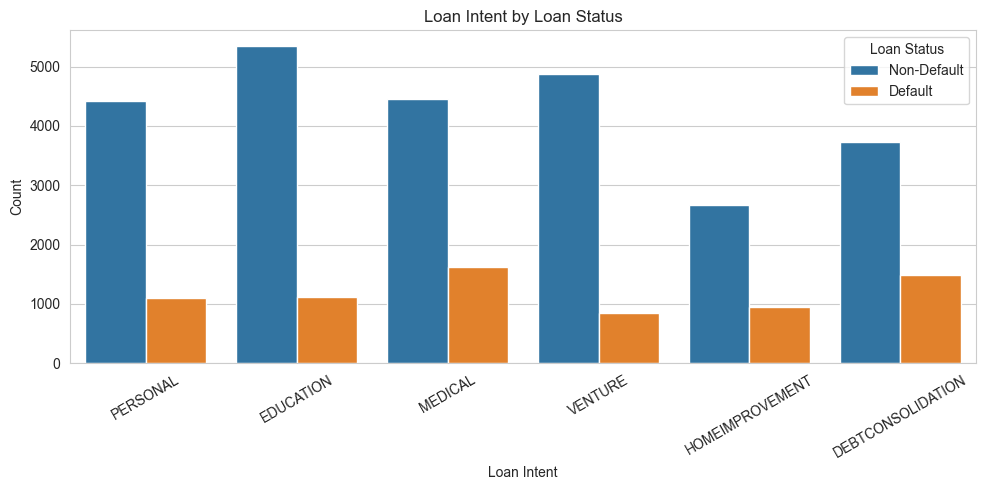

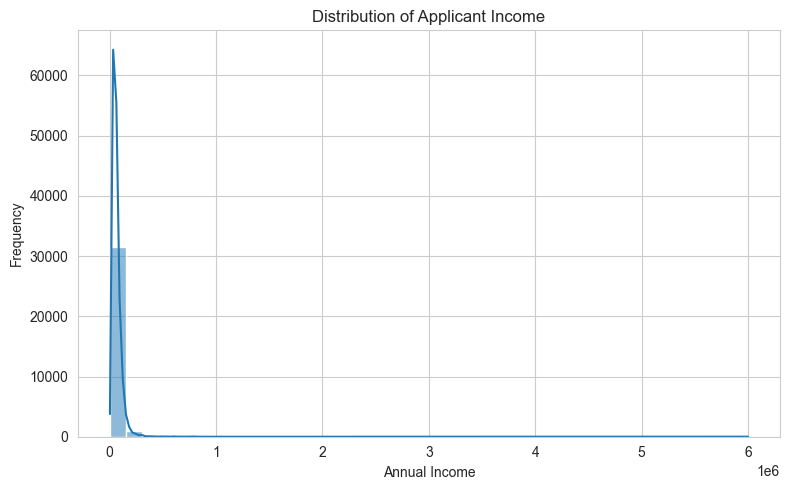

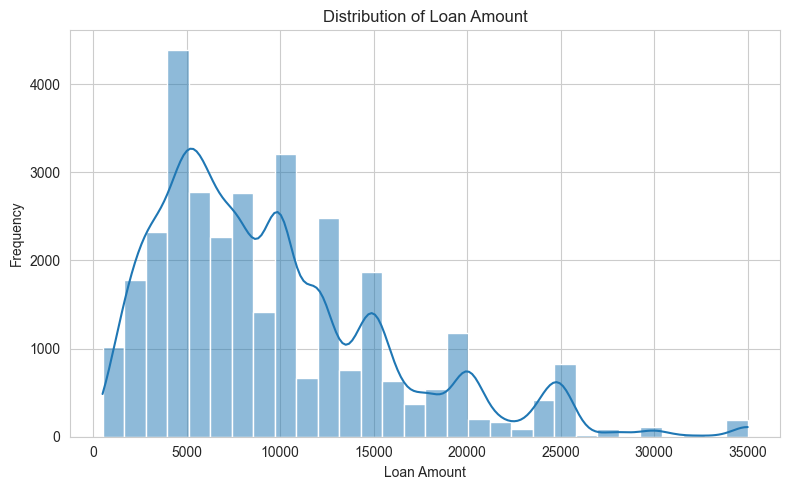

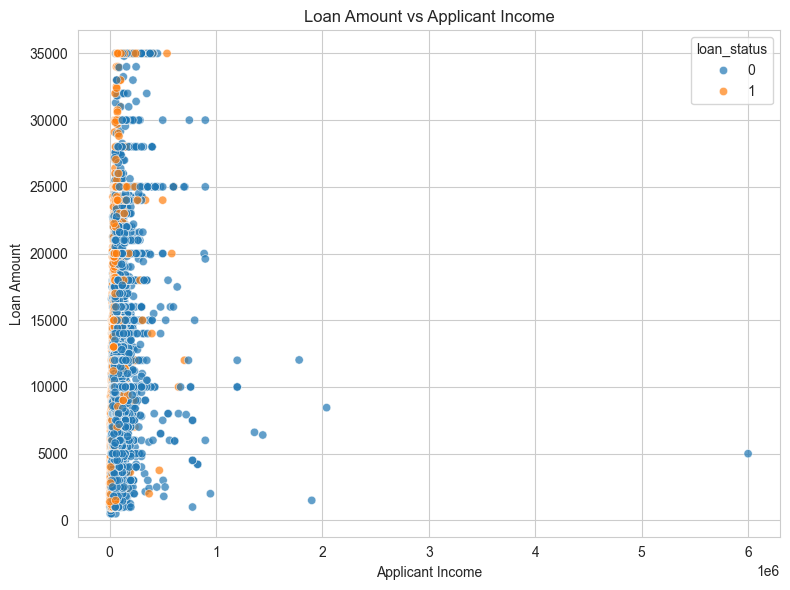

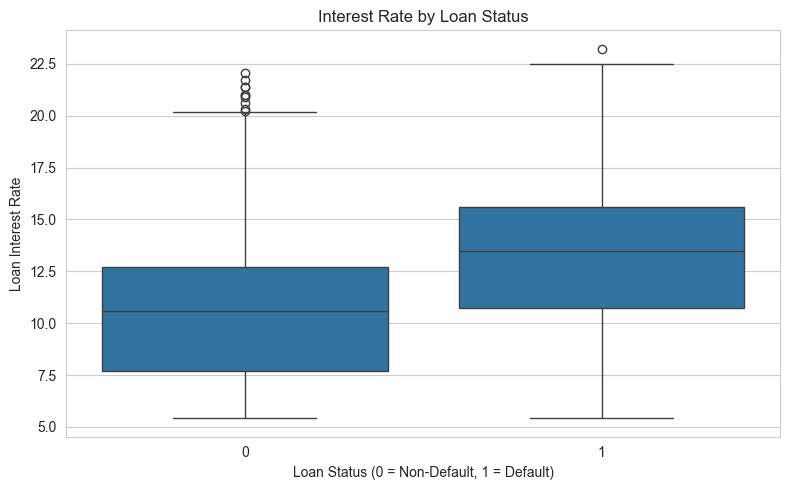

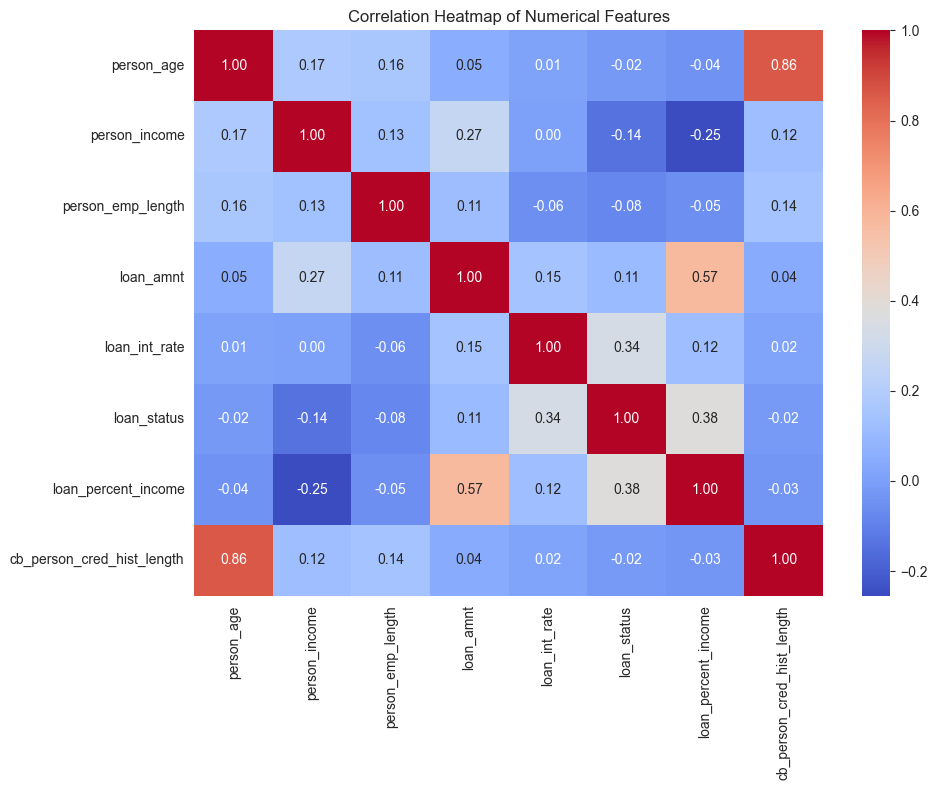

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset from GitHub
url = "https://raw.githubusercontent.com/DaneshBU/CS506-Project/main/data/credit_risk_dataset.csv"
df = pd.read_csv(url)


# Basic setup
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

# Preview data
display(df.head())

# Visualization 1 : Target variable distribution
plt.figure()
sns.countplot(data=df, x="loan_status")
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status (0 = Non-Default, 1 = Default)")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

# Visualization 2 : Loan intent by loan status
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="loan_intent", hue="loan_status")
plt.title("Loan Intent by Loan Status")
plt.xlabel("Loan Intent")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Loan Status", labels=["Non-Default", "Default"])
plt.tight_layout()
plt.show()

# Visualization 3 : Income distribution
plt.figure()
sns.histplot(df["person_income"], bins=40, kde=True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Visualization 4 : Loan amount distribution
plt.figure()
sns.histplot(df["loan_amnt"], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Visualization 5 : Income vs Loan Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="person_income",
    y="loan_amnt",
    hue="loan_status",
    alpha=0.7
)
plt.title("Loan Amount vs Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

# Visualization 6 : Boxplot of interest rate by loan status
plt.figure()
sns.boxplot(data=df, x="loan_status", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status (0 = Non-Default, 1 = Default)")
plt.ylabel("Loan Interest Rate")
plt.tight_layout()
plt.show()


# Visualization 7 : Correlation heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

Shape: (32581, 12)
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


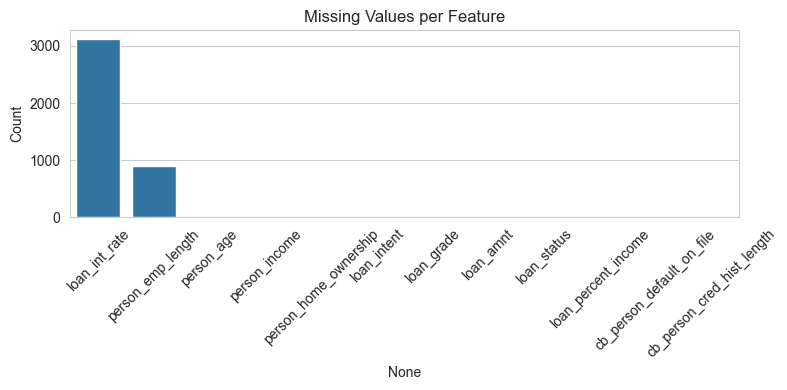

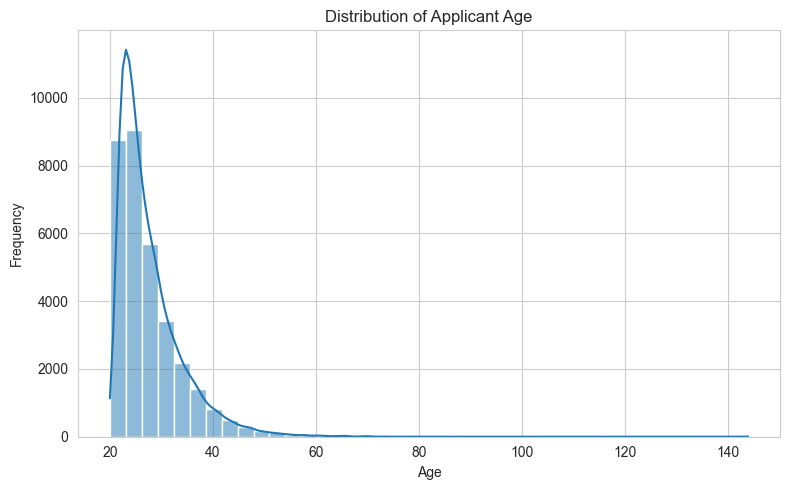

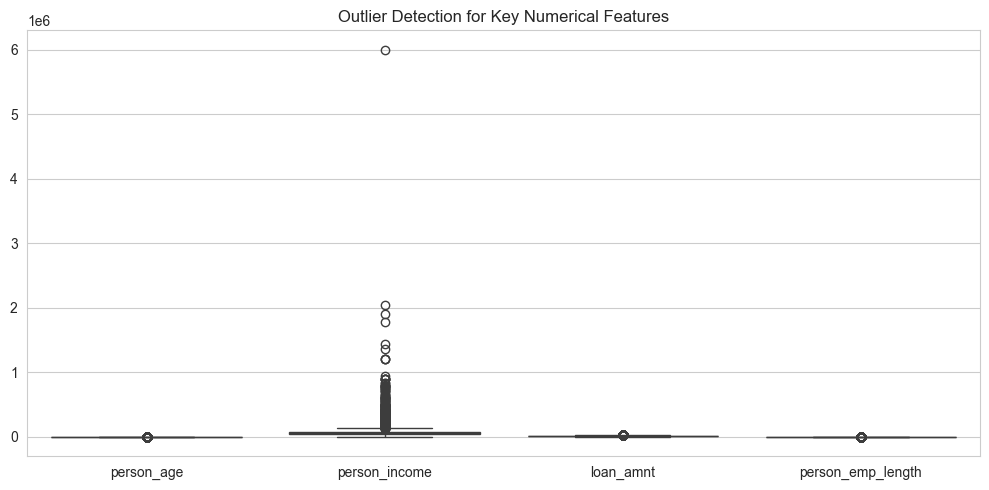

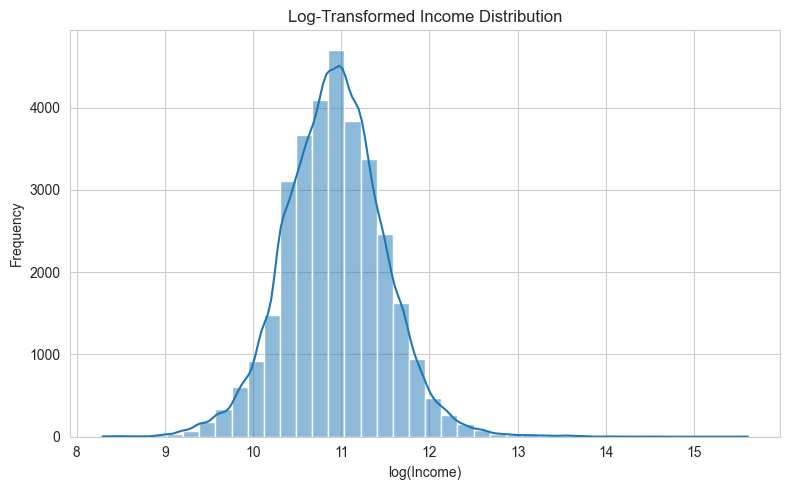

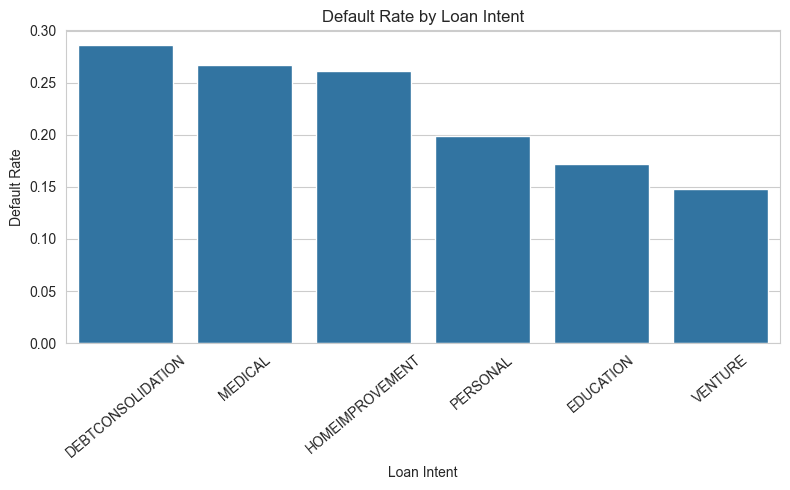

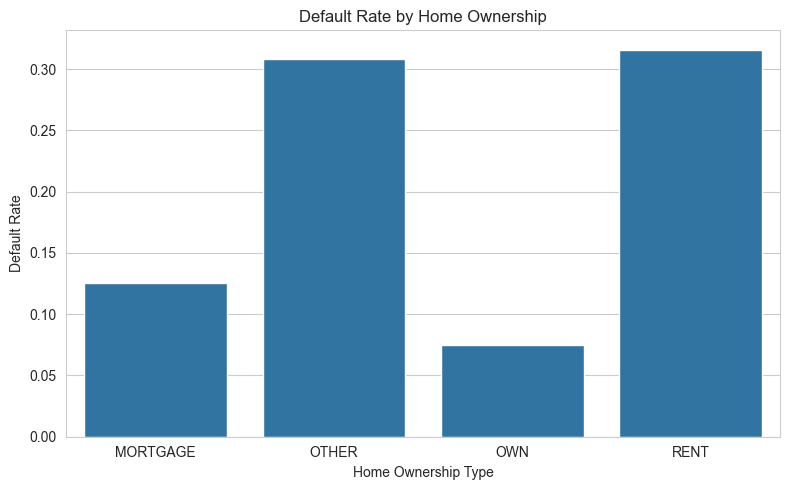

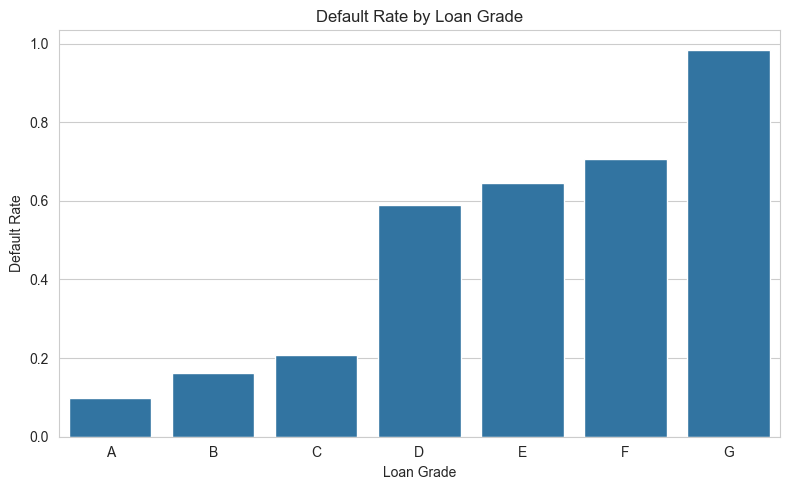

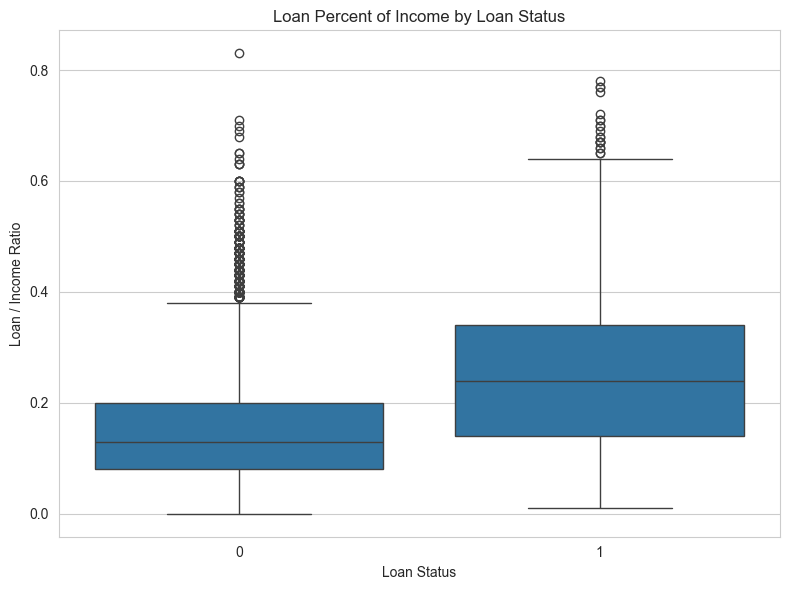

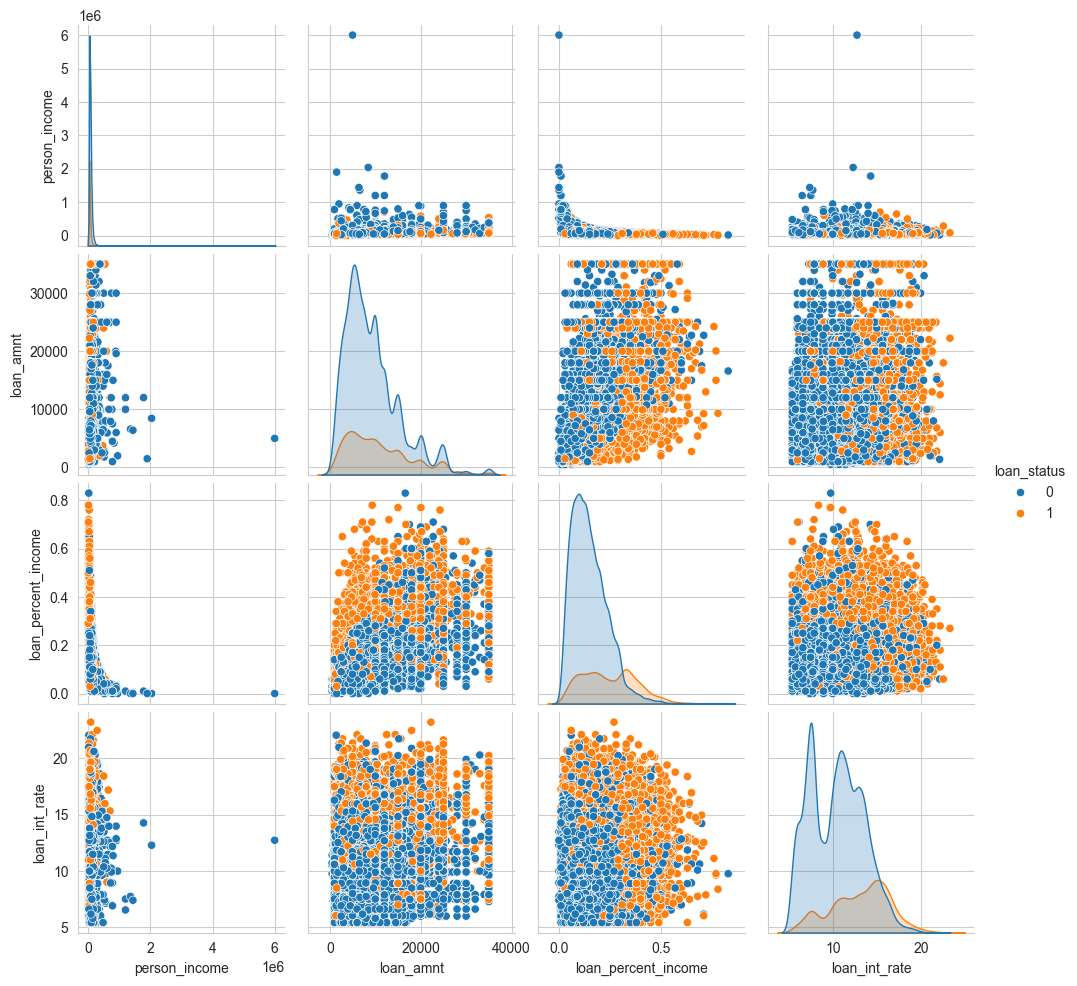

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/DaneshBU/CS506-Project/main/data/credit_risk_dataset.csv"
df = pd.read_csv(url)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Shape:", df.shape)
print(df.isnull().sum())

# Missing values bar chart
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Missing Values per Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Age distribution with outliers visible
plt.figure()
sns.histplot(df["person_age"], bins=40, kde=True)
plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplots to reveal outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["person_age","person_income","loan_amnt","person_emp_length"]])
plt.title("Outlier Detection for Key Numerical Features")
plt.tight_layout()
plt.show()

# Log-income distribution to correct skew
plt.figure()
sns.histplot(np.log1p(df["person_income"]), bins=40, kde=True)
plt.title("Log-Transformed Income Distribution")
plt.xlabel("log(Income)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Default rate by loan intent (proportion instead of raw counts)
intent_default = df.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=intent_default.index, y=intent_default.values)
plt.title("Default Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Default Rate")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

# Default rate by home ownership
ownership_default = df.groupby("person_home_ownership")["loan_status"].mean()

plt.figure()
sns.barplot(x=ownership_default.index, y=ownership_default.values)
plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership Type")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

# Default rate by loan grade
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index()

plt.figure()
sns.barplot(x=grade_default.index, y=grade_default.values)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

# Loan percent income vs default
plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title("Loan Percent of Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan / Income Ratio")
plt.tight_layout()
plt.show()

# Pairplot for key predictive variables
sns.pairplot(
    df[["person_income","loan_amnt","loan_percent_income","loan_int_rate","loan_status"]],
    hue="loan_status"
)
plt.show()

### **Default rate by income brackets**

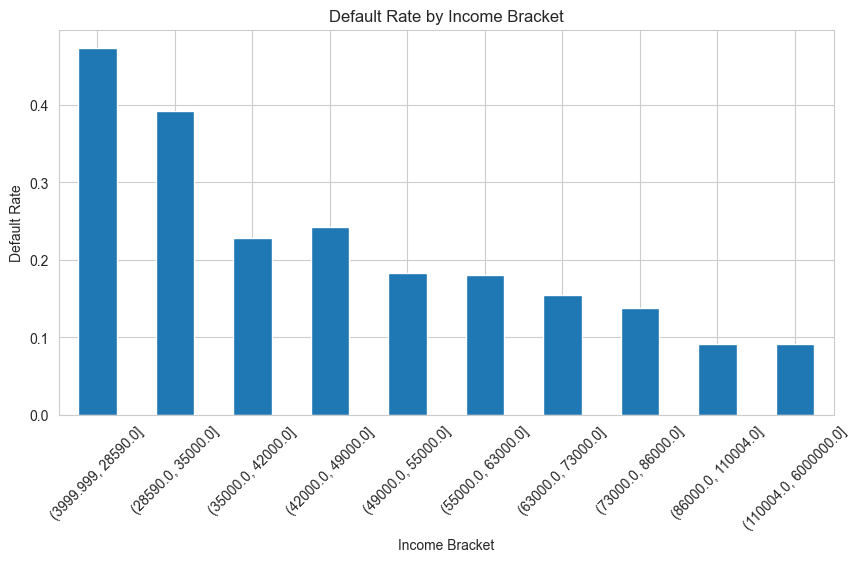

In [13]:
df["income_bin"] = pd.qcut(df["person_income"], 10)

income_default = df.groupby("income_bin")["loan_status"].mean()

plt.figure(figsize=(10,5))
income_default.plot(kind="bar")
plt.title("Default Rate by Income Bracket")
plt.xlabel("Income Bracket")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

### **Default rate by loan percent income**

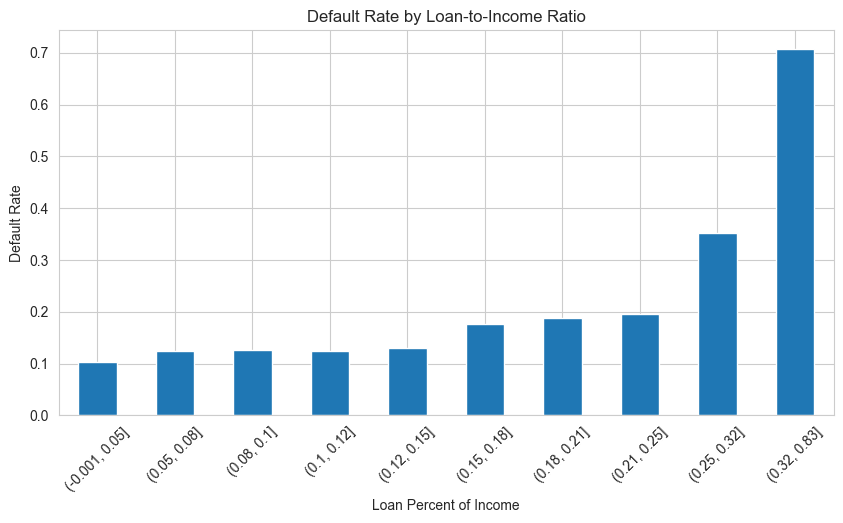

In [14]:
df["loan_percent_bin"] = pd.qcut(df["loan_percent_income"], 10)

risk = df.groupby("loan_percent_bin")["loan_status"].mean()

plt.figure(figsize=(10,5))
risk.plot(kind="bar")
plt.title("Default Rate by Loan-to-Income Ratio")
plt.xlabel("Loan Percent of Income")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

### **Default probability heatmap (Income vs Loan Amount)**

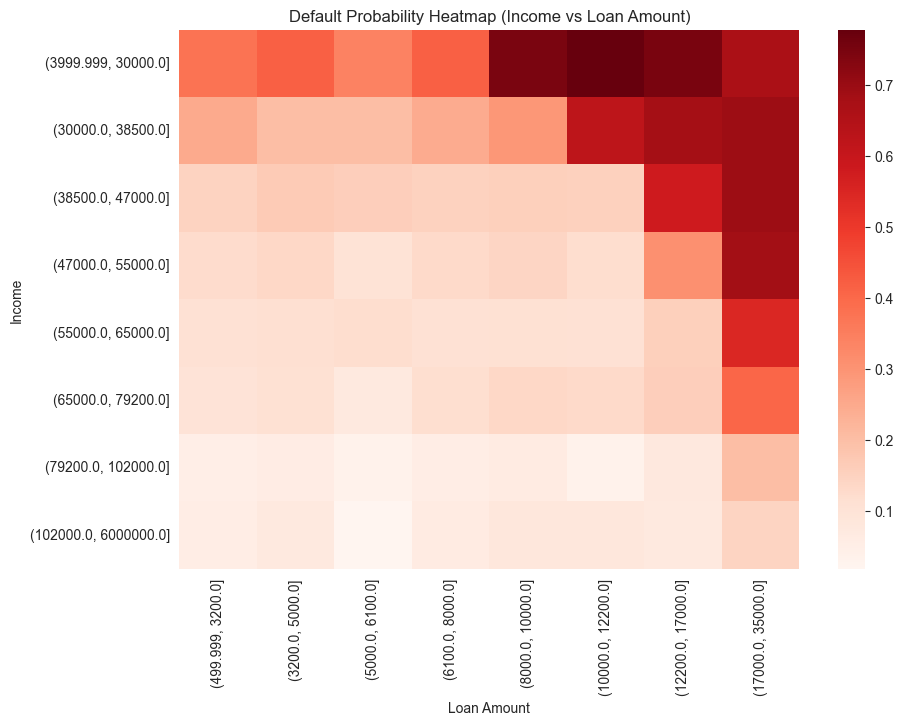

In [15]:
pivot = df.pivot_table(
    values="loan_status",
    index=pd.qcut(df["person_income"], 8),
    columns=pd.qcut(df["loan_amnt"], 8),
    aggfunc="mean"
)

plt.figure(figsize=(10,7))
sns.heatmap(pivot, cmap="Reds")
plt.title("Default Probability Heatmap (Income vs Loan Amount)")
plt.xlabel("Loan Amount")
plt.ylabel("Income")
plt.show()

### **Age vs Default Risk**

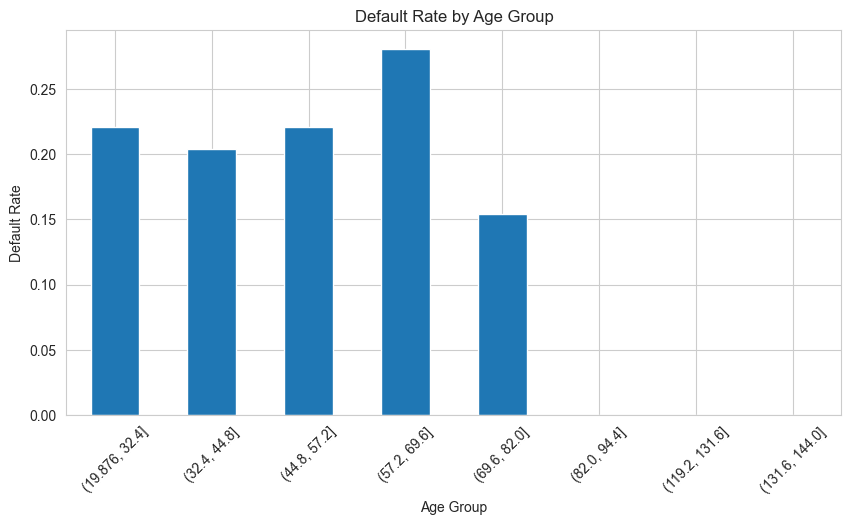

In [16]:
df["age_bin"] = pd.cut(df["person_age"], bins=10)

age_risk = df.groupby("age_bin")["loan_status"].mean()

plt.figure(figsize=(10,5))
age_risk.plot(kind="bar")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

### **Loan grade vs default rate**

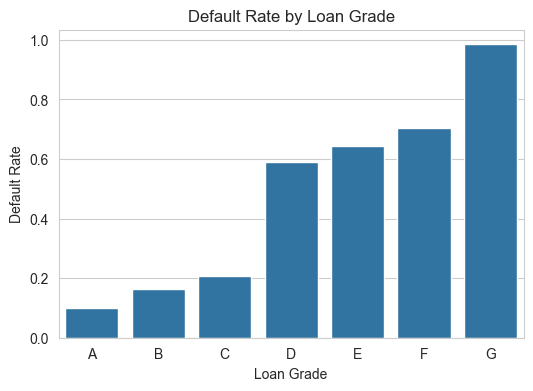

In [17]:
grade_risk = df.groupby("loan_grade")["loan_status"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=grade_risk.index, y=grade_risk.values)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

### **Home ownership vs default**

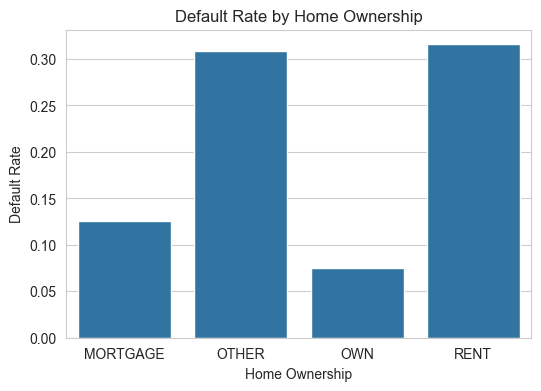

In [18]:
ownership_risk = df.groupby("person_home_ownership")["loan_status"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=ownership_risk.index, y=ownership_risk.values)
plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate")
plt.show()

### **Interest rate vs default probability**

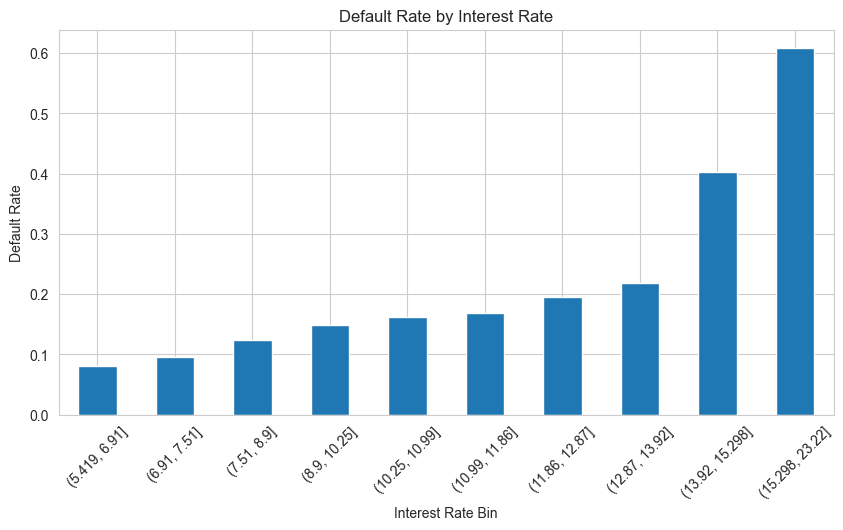

In [19]:
df["interest_bin"] = pd.qcut(df["loan_int_rate"], 10)

risk = df.groupby("interest_bin")["loan_status"].mean()

plt.figure(figsize=(10,5))
risk.plot(kind="bar")
plt.title("Default Rate by Interest Rate")
plt.xlabel("Interest Rate Bin")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

### **Missing value visualization**

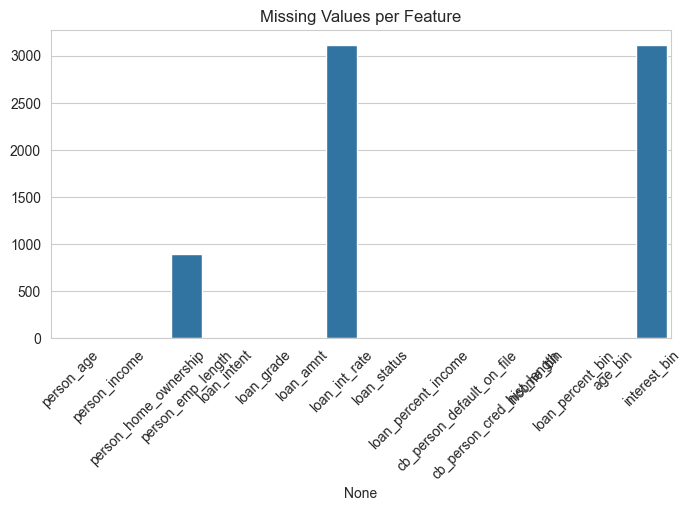

In [20]:
missing = df.isnull().sum()

plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45)
plt.title("Missing Values per Feature")
plt.show()

### **Outlier identification**

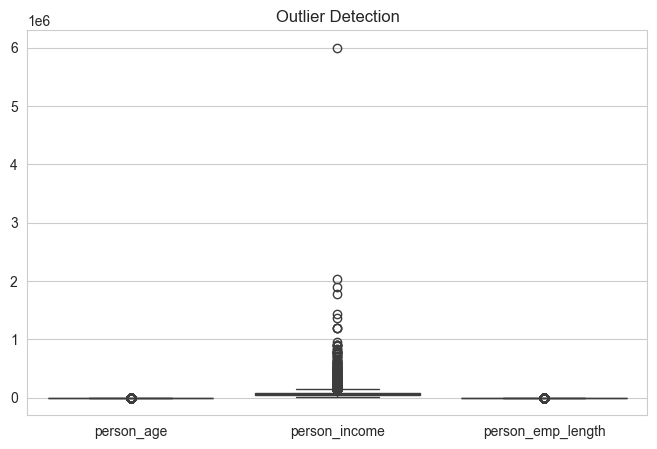

In [21]:
sns.boxplot(data=df[["person_age","person_income","person_emp_length"]])
plt.title("Outlier Detection")
plt.show()

### **Insights**



1.  **Income vs Default**\
lower income → higher default rate\
higher income → lower default rate\
Income strongly affects repayment ability.


2.   **Loan Percent of Income**\
higher loan_percent_income → sharply higher default risk\
If a loan consumes a large fraction of income, repayment becomes difficult.

3. **Income vs Loan Amount Heatmap**\
low income + high loan amount → highest default risk\
high income + moderate loan → lower risk\
Risk depends on interaction between income and loan size.

4. **Age vs Default**\
younger borrowers → slightly higher default risk\
older borrowers → more stable\
older borrowers often have a more stable income and credit history but persons age is a weak predictor.

5. **Loan Grade**\
A grade → lowest default\
G grade → highest default\
Loan grade already reflects credit risk assessment.

6. **Home Ownership**\
Typical pattern seen here: \
renters → higher default risk\
owners/mortgage → lower risk\
Home ownership indicates financial stability


7. **Interest Rate**\
higher interest rate → higher default probability\
High interest loans are given to riskier borrowers


### **Final Feature Selection Based on Insights**
- loan_percent_income
- loan_int_rate
- loan_grade
- person_income
- loan_amnt

### **Final Takeaway**
The visualization show default risk increases when
- low income
- high loan amount
- high loan-to-income ratio
- high interest rate
- poor loan grade  
